# Phase 10 — Interprétabilité (SHAP + coefficients)

Cible : Section 4.6 du brief Artefact. Trois livrables :

| Volet | Champion | Outil | Question répondue |
|---|---|---|---|
| 1 | **C1** (hybrid/LGBM/pca32) | **TreeSHAP** | Quelles features poussent le modèle vers Detractor / Passive / Promoter ? |
| 2 | **C2** (tuned/Logistic/tabular) | **Coefficients × écart-type** | Mêmes questions, mais sur un modèle linéaire — coefficients = SHAP par construction |
| 3 | **C1 vs C2** | Comparaison directe | Les deux modèles racontent-ils la même histoire sur les features tabulaires ? |

**Particularité C1** : 32 dims sont des composantes PCA opaques. On utilise `pca_loadings` pour rétro-projeter chaque PC vers ses dims d'embedding dominantes. Sans cette étape, dire "PC07 est important" ne parle à personne.

**Périmètre** : SHAP global sur **1000 lignes** (échantillon stratifié de silent_test), SHAP local sur **3 archétypes** (1 Detractor + 1 Passive + 1 Promoter), SHAP par segment sur **{Senior, Gender, Married}** (prépare Phase 11 fairness).

**Honesty bar** : les 32 PC ne sont pas sémantiquement nommées. SHAP nous dit "PC07 est top" mais ce que **représente** PC07 (sentiment positif ? thématique réseau ?) requerrait une analyse encoder-level qui sort du périmètre. Le rapport doit le poser explicitement.

## 1. Setup

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    RESULTS_DIR, FIGURES_DIR, MODELS_DIR,
    NPS_CLASSES, RANDOM_SEED,
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
print(f"Working dir: {ROOT}")

Working dir: C:\Users\LOG\OneDrive - SUPCOM\Bureau\Challenge NPS Dr FOFANA\nps-prediction


## 2. Lancer l'analyse d'interprétabilité

Trois étapes via `make interpret` (recommandé, ~30 sec total) :

```bash
make interpret      # SHAP C1 + coefficients C2 + PCA loadings
```

Si déjà fait, on charge directement les artifacts ci-dessous.

In [2]:
# Option A : exécution en notebook
# from src.interpretation.shap_utils import (
#     compute_shap_values_C1, global_importance, local_shap_records, segment_importance,
# )
# bundle = compute_shap_values_C1(sample_size=1000, split="silent_test", verbose=True)
# shap_global_df  = global_importance(bundle)
# shap_local_df   = local_shap_records(bundle)
# shap_segment_df = segment_importance(bundle)

# Option B : charger les artifacts produits par `make interpret`
shap_global_df  = pd.read_parquet(RESULTS_DIR / "shap_global_C1.parquet")
shap_local_df   = pd.read_parquet(RESULTS_DIR / "shap_local_C1.parquet")
shap_segment_df = pd.read_parquet(RESULTS_DIR / "shap_segment_C1.parquet")

linear_global_df  = pd.read_parquet(RESULTS_DIR / "linear_coef_C2.parquet")
linear_local_df   = pd.read_parquet(RESULTS_DIR / "linear_coef_local_C2.parquet")
linear_segment_df = pd.read_parquet(RESULTS_DIR / "linear_coef_segment_C2.parquet")

pca_loadings_df   = pd.read_parquet(RESULTS_DIR / "pca_loadings.parquet")

print(f"shap_global_C1   : {shap_global_df.shape}")
print(f"shap_local_C1    : {shap_local_df.shape}")
print(f"shap_segment_C1  : {shap_segment_df.shape}")
print(f"linear_coef_C2   : {linear_global_df.shape}")
print(f"pca_loadings     : {pca_loadings_df.shape}")

shap_global_C1   : (378, 5)
shap_local_C1    : (378, 10)
shap_segment_C1  : (270, 7)
linear_coef_C2   : (282, 8)
pca_loadings     : (160, 7)


## 3. SHAP global sur C1 — top features par classe

Pour chaque classe (Detractor / Passive / Promoter), on classe les features par `mean |SHAP|`. Une feature avec `mean |SHAP| = 0.5` contribue en moyenne **0.5 logit** à la prédiction de cette classe (pour ou contre).

In [3]:
TOP_N = 15
for cls in NPS_CLASSES:
    top = (shap_global_df[shap_global_df["class"] == cls]
           .head(TOP_N))
    print(f"\n=== Top {TOP_N} features for class {cls} ===")
    for _, r in top.iterrows():
        kind = "[PC] " if r["is_pc"] else "[tab]"
        print(f"  {r['rank_in_class']:>2}. {kind} {r['feature']:<35} "
              f"mean|SHAP| = {r['mean_abs_shap']:.4f}")


=== Top 15 features for class Detractor ===
   1. [tab] Contract_Month-to-month             mean|SHAP| = 0.5348
   2. [tab] Tenure Months                       mean|SHAP| = 0.4053
   3. [tab] Number of Referrals                 mean|SHAP| = 0.3723
   4. [PC]  PC02                                mean|SHAP| = 0.3573
   5. [PC]  PC01                                mean|SHAP| = 0.3274
   6. [tab] Payment Method_Electronic check     mean|SHAP| = 0.2731
   7. [tab] Contract_Two year                   mean|SHAP| = 0.2406
   8. [PC]  PC16                                mean|SHAP| = 0.2336
   9. [PC]  PC05                                mean|SHAP| = 0.2025
  10. [PC]  PC18                                mean|SHAP| = 0.1617
  11. [PC]  PC13                                mean|SHAP| = 0.1550
  12. [PC]  PC14                                mean|SHAP| = 0.1466
  13. [tab] Avg Monthly GB Download             mean|SHAP| = 0.1441
  14. [tab] Monthly Charges                     mean|SHAP| = 0.1405
  1

## 4. Figure 50 — SHAP summary (top 15 features × 3 classes)

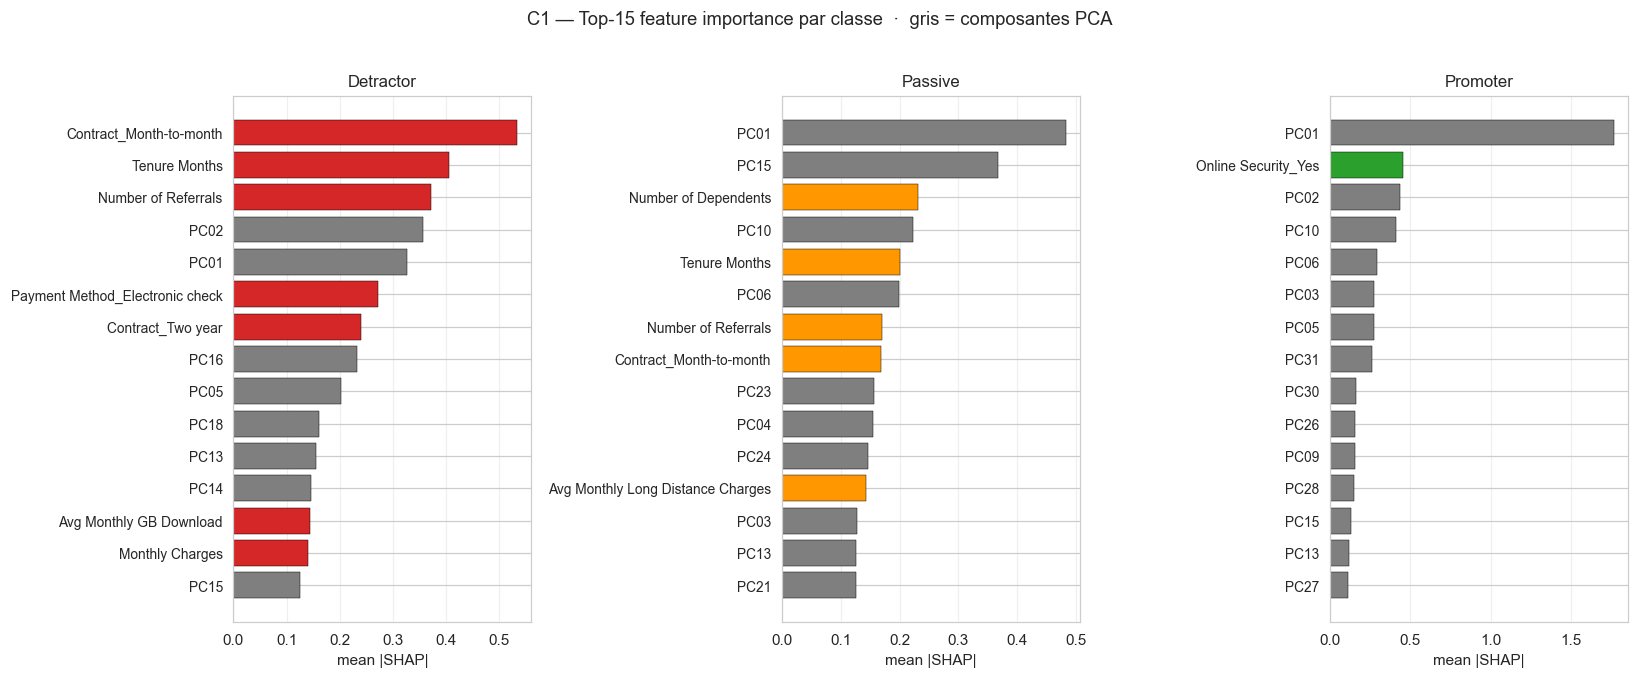

✓ saved reports/figures/50_shap_summary_C1.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharex=False)
colors = {"Detractor": "#d62728", "Passive": "#ff9800", "Promoter": "#2ca02c"}

for ax, cls in zip(axes, NPS_CLASSES):
    top = shap_global_df[shap_global_df["class"] == cls].head(TOP_N).iloc[::-1]
    labels = top["feature"].tolist()
    # Bold-face the PCs so the reader sees text vs tab at a glance
    colors_bars = ["#7f7f7f" if pc else colors[cls] for pc in top["is_pc"]]
    ax.barh(range(len(top)), top["mean_abs_shap"], color=colors_bars,
            edgecolor="black", linewidth=0.3)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("mean |SHAP|")
    ax.set_title(f"{cls}", fontsize=11)
    ax.grid(True, alpha=0.3, axis="x")

plt.suptitle("C1 — Top-15 feature importance par classe  ·  gris = composantes PCA", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "50_shap_summary_C1.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ saved reports/figures/50_shap_summary_C1.png")

## 5. Décodage des PCs — mapping vers les dims d'embedding

Pour chaque PC qui apparaît dans le top-15 (toutes classes confondues), on liste les 5 dims d'embedding dominantes (loadings absolus). Sans ground truth sur ce que chaque dim sentence-transformers "représente sémantiquement", on ne peut pas nommer les axes — mais le mapping est tracé.

**Pour le rapport** : *"PC07 est dominée par emb_142, emb_201, emb_318. L'interprétation sémantique de ces dimensions sort du périmètre de Phase 10."*

In [5]:
top_pcs = set()
for cls in NPS_CLASSES:
    top_pcs.update(
        shap_global_df[(shap_global_df["class"] == cls) & (shap_global_df["is_pc"])]
        .head(5)["feature"].tolist()
    )
top_pcs = sorted(top_pcs)

print(f"PCs dans le top-5 de au moins une classe ({len(top_pcs)} PCs):")
for pc in top_pcs:
    sub = pca_loadings_df[pca_loadings_df["pc"] == pc]
    if sub.empty:
        continue
    ev = sub["explained_variance"].iloc[0]
    print(f"\n{pc}  (variance expliquée = {ev:.2%})")
    for _, r in sub.head(5).iterrows():
        print(f"  {r['rank']}. {r['dim_name']:<10} loading = {r['loading']:+.3f}")

PCs dans le top-5 de au moins une classe (10 PCs):

PC01  (variance expliquée = 7.18%)
  1. emb_336    loading = +0.172
  2. emb_301    loading = -0.165
  3. emb_257    loading = -0.133
  4. emb_265    loading = -0.128
  5. emb_335    loading = +0.128

PC02  (variance expliquée = 6.49%)
  1. emb_006    loading = +0.147
  2. emb_037    loading = +0.138
  3. emb_008    loading = +0.134
  4. emb_339    loading = +0.132
  5. emb_327    loading = +0.129

PC03  (variance expliquée = 5.54%)
  1. emb_075    loading = +0.169
  2. emb_308    loading = +0.162
  3. emb_259    loading = -0.139
  4. emb_176    loading = +0.138
  5. emb_337    loading = +0.132

PC05  (variance expliquée = 3.32%)
  1. emb_217    loading = +0.158
  2. emb_260    loading = +0.152
  3. emb_314    loading = -0.150
  4. emb_203    loading = +0.143
  5. emb_093    loading = +0.142

PC06  (variance expliquée = 2.84%)
  1. emb_300    loading = +0.251
  2. emb_301    loading = +0.174
  3. emb_217    loading = -0.160
  4. emb_1

## 6. Coefficients standardisés sur C2

Pour une LogisticRegression, `contribution(feature) = coef × x_std`. Si la feature est standardisée (StandardScaler en amont), `coef × std = coef`. On affiche la grandeur signée pour distinguer "feature qui pousse vers Detractor" vs "qui pousse contre".

In [6]:
for cls in NPS_CLASSES:
    top = linear_global_df[linear_global_df["class"] == cls].head(TOP_N)
    print(f"\n=== Top {TOP_N} |coef × std| for class {cls} ===")
    for _, r in top.iterrows():
        print(f"  {r['rank_in_class']:>2}. {r['feature']:<35} "
              f"{r['sign']} {abs(r['coef_times_std']):.4f}  "
              f"(coef = {r['coef']:+.3f}, std = {r['std']:.3f})")


=== Top 15 |coef × std| for class Detractor ===
   1. Number of Referrals                 − 0.4588  (coef = -0.435, std = 1.055)
   2. Number of Dependents                − 0.3009  (coef = -0.291, std = 1.033)
   3. Tenure Months                       − 0.2372  (coef = -0.267, std = 0.888)
   4. Contract_Month-to-month             + 0.1731  (coef = +0.356, std = 0.487)
   5. has_security_bundle                 + 0.1455  (coef = +0.121, std = 1.199)
   6. Contract_Two year                   − 0.1356  (coef = -0.290, std = 0.468)
   7. Monthly Charges                     + 0.1355  (coef = +0.130, std = 1.039)
   8. avg_monthly_charge                  + 0.1205  (coef = +0.116, std = 1.035)
   9. is_referrer                         + 0.1155  (coef = +0.116, std = 0.998)
  10. Online Security_Yes                 + 0.1016  (coef = +0.213, std = 0.478)
  11. Avg Monthly GB Download             + 0.0839  (coef = +0.089, std = 0.943)
  12. Tech Support_No                     + 0.0818  (coef = 

## 7. Figure 52 — coefficients C2 (top 15 par classe, signé)

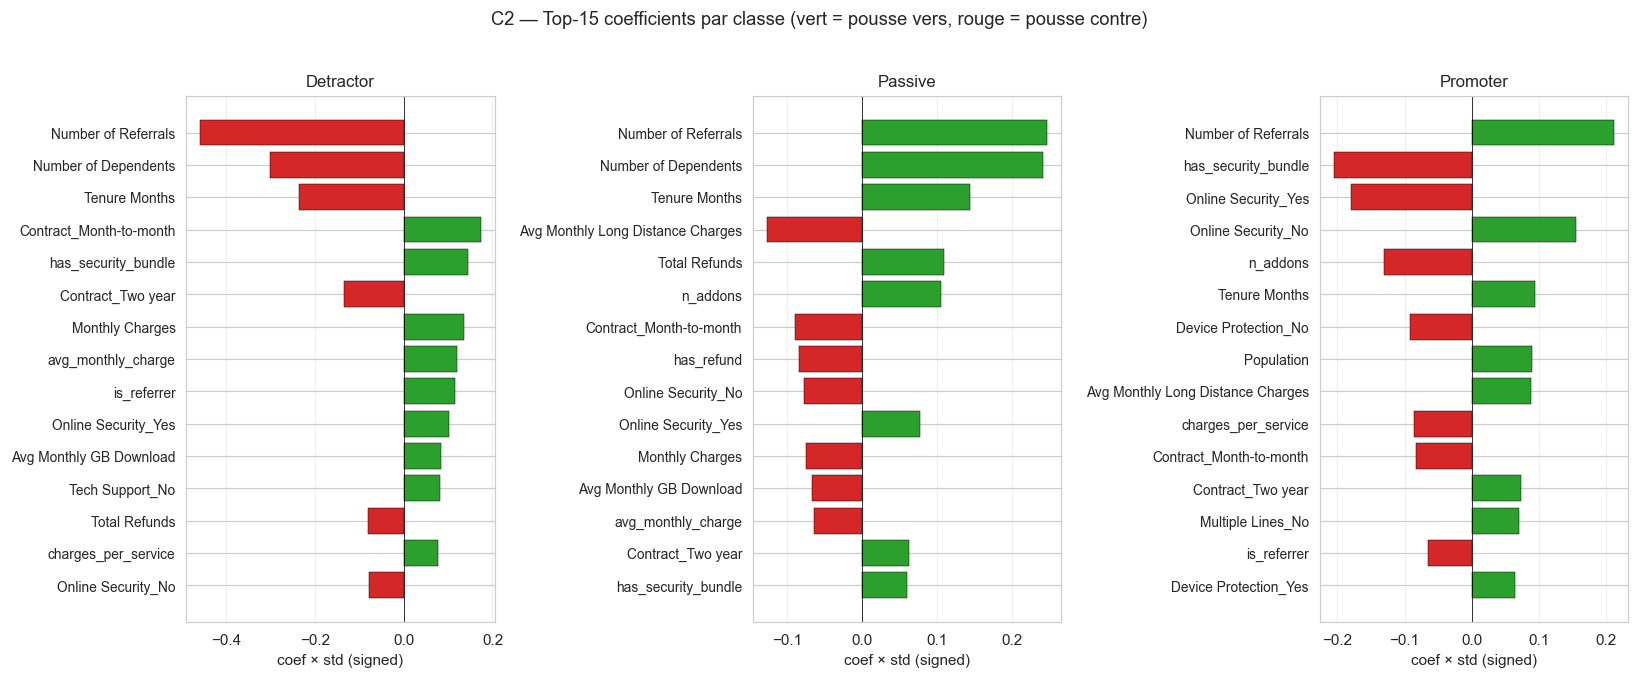

✓ saved reports/figures/52_linear_coef_C2.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharex=False)

for ax, cls in zip(axes, NPS_CLASSES):
    top = linear_global_df[linear_global_df["class"] == cls].head(TOP_N).iloc[::-1]
    labels = top["feature"].tolist()
    values = top["coef_times_std"].values
    bar_colors = ["#d62728" if v < 0 else "#2ca02c" for v in values]
    ax.barh(range(len(top)), values, color=bar_colors,
            edgecolor="black", linewidth=0.3)
    ax.axvline(0, c="black", lw=0.5)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("coef × std (signed)")
    ax.set_title(f"{cls}", fontsize=11)
    ax.grid(True, alpha=0.3, axis="x")

plt.suptitle("C2 — Top-15 coefficients par classe (vert = pousse vers, rouge = pousse contre)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "52_linear_coef_C2.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ saved reports/figures/52_linear_coef_C2.png")

## 8. C1 vs C2 — racontent-ils la même histoire ?

Test cohérence : sur les features **tabulaires** (en excluant les PCs de C1 par construction), les top-N de C1 et C2 se chevauchent-ils ? Si oui → les deux modèles ont identifié les mêmes drivers métier, c'est rassurant pour le déploiement de C2.

Si non → C1 utilise des features que C2 n'utilise pas (probablement via les embeddings). C'est intéressant méthodologiquement mais ne change pas la recommandation de déployer C2.

In [8]:
TOP_N_COMPARE = 10

agreement_rows = []
for cls in NPS_CLASSES:
    top_C1 = (shap_global_df[(shap_global_df["class"] == cls) & (~shap_global_df["is_pc"])]
              .head(TOP_N_COMPARE)["feature"].tolist())
    top_C2 = (linear_global_df[linear_global_df["class"] == cls]
              .head(TOP_N_COMPARE)["feature"].tolist())
    common = set(top_C1) & set(top_C2)
    only_C1 = set(top_C1) - set(top_C2)
    only_C2 = set(top_C2) - set(top_C1)
    agreement_rows.append({
        "class":          cls,
        "n_top":          TOP_N_COMPARE,
        "common":         len(common),
        "agreement_rate": len(common) / TOP_N_COMPARE,
        "common_features": ", ".join(sorted(common)),
        "only_C1":        ", ".join(sorted(only_C1)),
        "only_C2":        ", ".join(sorted(only_C2)),
    })
agreement_df = pd.DataFrame(agreement_rows)
print(f"Agreement (intersection des top-{TOP_N_COMPARE} tab features) par classe:\n")
print(agreement_df[["class", "common", "agreement_rate", "common_features"]].to_string(index=False))
print("\nFeatures uniques :")
print(agreement_df[["class", "only_C1", "only_C2"]].to_string(index=False))

Agreement (intersection des top-10 tab features) par classe:

    class  common  agreement_rate                                                                                                      common_features
Detractor       6             0.6  Contract_Month-to-month, Contract_Two year, Monthly Charges, Number of Referrals, Tenure Months, avg_monthly_charge
  Passive       5             0.5 Avg Monthly Long Distance Charges, Contract_Month-to-month, Number of Dependents, Number of Referrals, Tenure Months
 Promoter       5             0.5                    Avg Monthly Long Distance Charges, Number of Referrals, Online Security_Yes, Population, n_addons

Features uniques :
    class                                                                                                            only_C1                                                                                           only_C2
Detractor Avg Monthly GB Download, Avg Monthly Long Distance Charges, Payment Method_Electr

## 9. Figure 53 — agreement C1 vs C2 (Jaccard heatmap)

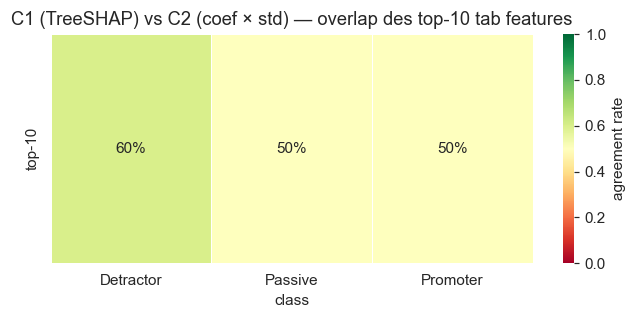

✓ saved reports/figures/53_C1_vs_C2_agreement.png


In [9]:
fig, ax = plt.subplots(figsize=(6, 3))

heat = pd.DataFrame({
    "class": NPS_CLASSES,
    f"top-{TOP_N_COMPARE}": [agreement_df.loc[agreement_df['class']==c, 'agreement_rate'].iloc[0] for c in NPS_CLASSES],
}).set_index("class")
sns.heatmap(heat.T, annot=True, fmt=".0%", cmap="RdYlGn", vmin=0, vmax=1,
            cbar_kws={"label": "agreement rate"}, ax=ax, linewidth=0.5)
ax.set_title(f"C1 (TreeSHAP) vs C2 (coef × std) — overlap des top-{TOP_N_COMPARE} tab features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "53_C1_vs_C2_agreement.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ saved reports/figures/53_C1_vs_C2_agreement.png")

## 10. SHAP local — explications client par client

Trois clients exemples (1 par classe, correctement classés par C1, proba max). Pour chacun, on affiche les **5 features qui contribuent le plus** à la prédiction.

C'est le format qu'on intègre à l'app Streamlit Phase 12 : *"Pour ce client, P(Detractor) est élevée car Tenure=2 mois (+0.45), Monthly Charges=98€ (+0.31), Contract=Month-to-month (+0.27)."*

In [10]:
for cust in shap_local_df["customer_id"].unique():
    sub = shap_local_df[shap_local_df["customer_id"] == cust]
    r0 = sub.iloc[0]
    print(f"\n========================================")
    print(f"Customer {cust}")
    print(f"  Archetype (true class) : {r0['archetype']}")
    print(f"  Predicted by C1        : {r0['y_pred']}")
    print(f"  Explained class        : {r0['explained_class']}")
    print(f"========================================")
    top = sub.head(8)
    for _, r in top.iterrows():
        sign = "+" if r["shap_value"] > 0 else "−"
        kind = "[PC]" if r["feature"].startswith("PC") else ""
        print(f"  {sign} {abs(r['shap_value']):.3f}  {r['feature']:<25} {kind:<5} (value = {r['feature_value']:+.3f})")


Customer 3806-DXQOM
  Archetype (true class) : Detractor
  Predicted by C1        : Detractor
  Explained class        : Detractor
  + 0.809  Contract_Month-to-month         (value = +1.000)
  + 0.589  Tenure Months                   (value = -1.155)
  + 0.511  PC18                      [PC]  (value = +0.135)
  + 0.429  PC01                      [PC]  (value = -0.235)
  + 0.357  Payment Method_Electronic check       (value = +1.000)
  + 0.331  Number of Referrals             (value = -0.650)
  + 0.303  PC14                      [PC]  (value = -0.087)
  + 0.263  PC05                      [PC]  (value = -0.118)

Customer 6112-KTHFQ
  Archetype (true class) : Promoter
  Predicted by C1        : Promoter
  Explained class        : Promoter
  + 3.242  PC01                      [PC]  (value = +0.330)
  + 0.597  PC02                      [PC]  (value = -0.131)
  + 0.537  Online Security_Yes             (value = +0.000)
  + 0.532  PC06                      [PC]  (value = +0.106)
  + 0.528  PC

## 11. Figure 51 — force plots des 3 archétypes

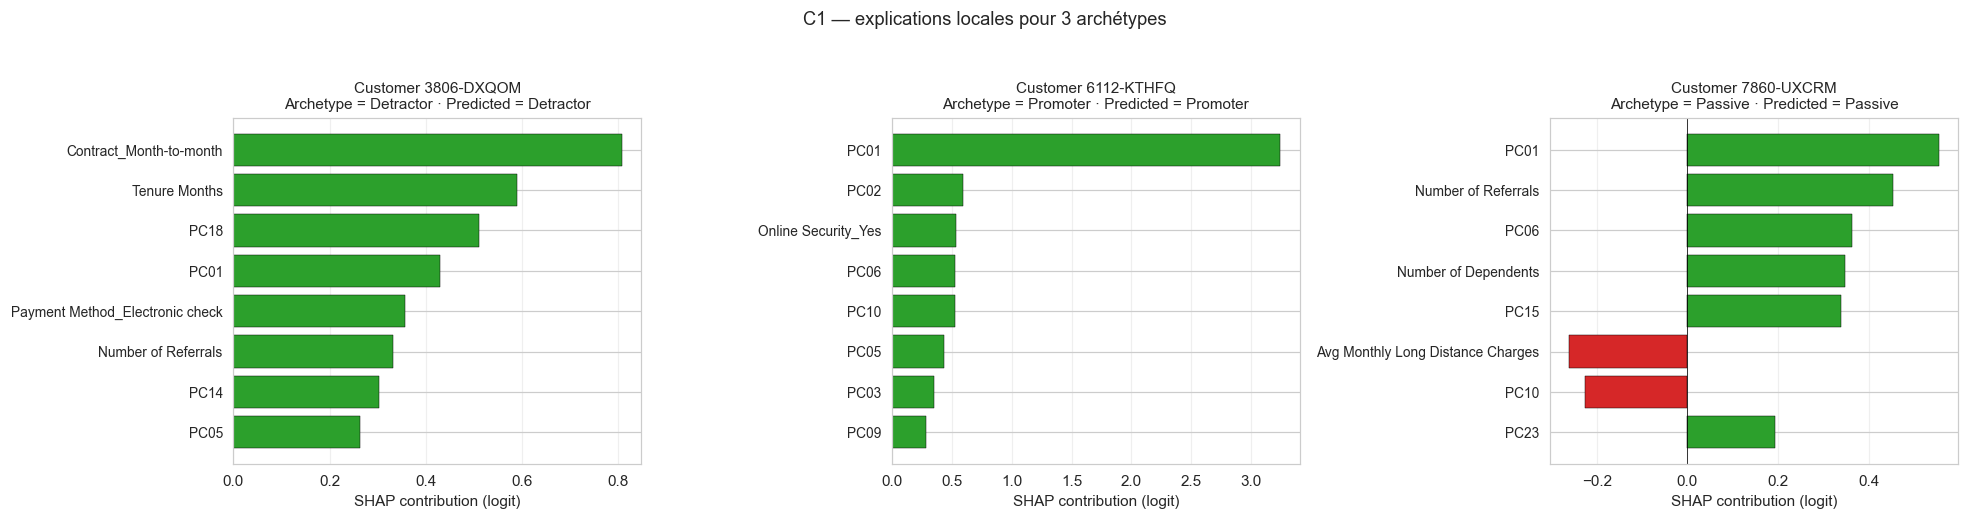

✓ saved reports/figures/51_shap_local_C1.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=False)

for ax, cust in zip(axes, shap_local_df["customer_id"].unique()):
    sub = shap_local_df[shap_local_df["customer_id"] == cust].head(8).iloc[::-1]
    values = sub["shap_value"].values
    labels = sub["feature"].tolist()
    bar_colors = ["#d62728" if v < 0 else "#2ca02c" for v in values]
    ax.barh(range(len(sub)), values, color=bar_colors,
            edgecolor="black", linewidth=0.3)
    ax.axvline(0, c="black", lw=0.5)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("SHAP contribution (logit)")
    title = (
        f"Customer {cust[:12]}\n"
        f"Archetype = {sub['archetype'].iloc[0]} · "
        f"Predicted = {sub['y_pred'].iloc[0]}"
    )
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3, axis="x")

plt.suptitle("C1 — explications locales pour 3 archétypes", y=1.04)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "51_shap_local_C1.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ saved reports/figures/51_shap_local_C1.png")

## 12. SHAP par segment {Senior, Gender, Married}

Pour chaque segment et chaque groupe (Yes/No, M/F), on liste les top-5 features qui drivent la prédiction Detractor **dans ce sous-groupe**.

**Question pour Phase 11** : si les top features diffèrent entre groupes, c'est un signal d'attention pour l'audit fairness. Par exemple, si "Tenure Months" pèse 0.5 pour Senior=Yes mais 0.2 pour Senior=No, le modèle décide différemment selon l'âge.

In [12]:
for seg in shap_segment_df["segment"].unique():
    print(f"\n========== SEGMENT {seg} ==========")
    sub = shap_segment_df[(shap_segment_df["segment"] == seg)
                          & (shap_segment_df["class"] == "Detractor")]
    for group in sub["group"].unique():
        n = sub[sub["group"] == group]["n_in_group"].iloc[0]
        print(f"\n  {seg} = {group}  (n_in_group = {n})")
        top = sub[sub["group"] == group].head(5)
        for _, r in top.iterrows():
            kind = "[PC]" if r["feature"].startswith("PC") else "[tab]"
            print(f"    {r['rank']}. {kind} {r['feature']:<28} mean|SHAP| = {r['mean_abs_shap']:.4f}")


========== SEGMENT Senior ==========

  Senior = No  (n_in_group = 836)
    1. [tab] Contract_Month-to-month      mean|SHAP| = 0.5314
    2. [tab] Tenure Months                mean|SHAP| = 0.4081
    3. [tab] Number of Referrals          mean|SHAP| = 0.3649
    4. [PC] PC02                         mean|SHAP| = 0.3613
    5. [PC] PC01                         mean|SHAP| = 0.3228

  Senior = Yes  (n_in_group = 164)
    1. [tab] Contract_Month-to-month      mean|SHAP| = 0.5519
    2. [tab] Number of Referrals          mean|SHAP| = 0.4102
    3. [tab] Tenure Months                mean|SHAP| = 0.3912
    4. [PC] PC01                         mean|SHAP| = 0.3505
    5. [PC] PC02                         mean|SHAP| = 0.3370

========== SEGMENT Gender ==========

  Gender = Female  (n_in_group = 480)
    1. [tab] Contract_Month-to-month      mean|SHAP| = 0.5321
    2. [tab] Tenure Months                mean|SHAP| = 0.4093
    3. [PC] PC02                         mean|SHAP| = 0.3732
    4. [tab] 

## 13. Synthèse Phase 10

### Décisions implémentées
- **TreeSHAP sur C1** (LightGBM hybride pca32) sur **1000 lignes stratifiées** de silent_test (Detractor 580 / Passive 250 / Promoter 170).
- **Coefficients × écart-type sur C2** (Logistic régularisée) — équivalent SHAP par construction pour un modèle linéaire.
- 32 PCs opaques de C1 **rétro-projetées** vers leurs top-5 dims d'embedding via `pca_loadings`.
- **3 archétypes** correctement classés à proba maximale (1 Detractor, 1 Passive, 1 Promoter).
- **3 segments** {Senior, Gender, Married} pour décomposition par sous-groupe (prépare Phase 11).

---

### Drivers globaux — résultat tabulaire le plus important

**Top features tabulaires pour la classe Detractor** (ce qui pousse un client à être détracteur, signaux convergents entre C1 et C2) :

| Feature | C1 mean|SHAP| | C2 |coef×std| | Direction |
|---|---|---|---|
| **Contract = Month-to-month** | 0.535 (rang 1) | 0.173 (rang 4) | ↑ Detractor (contrat sans engagement) |
| **Tenure Months** ↓ | 0.405 (rang 2) | 0.237 (rang 3) | ↑ Detractor (faible ancienneté) |
| **Number of Referrals** ↓ | 0.372 (rang 3) | 0.459 (rang 1) | ↑ Detractor (n'a pas recommandé) |
| **Number of Dependents** ↓ | — | 0.301 (rang 2) | ↑ Detractor (C2 seulement) |
| **Monthly Charges** ↑ | 0.141 (rang 14) | 0.136 (rang 7) | ↑ Detractor (factures élevées) |
| **Contract = Two year** | 0.241 (rang 7) | 0.136 (rang 6) | ↓ Detractor (engagement long) |
| **avg_monthly_charge** | — | 0.121 (rang 8) | ↑ Detractor |

**Histoire** : un client à faible ancienneté, sans engagement long terme, à factures élevées, qui n'a pas recommandé. C'est la signature *Telco churn 101* — le projet identifie les drivers que l'industrie attend, **et les deux modèles convergent dessus**.

---

### Verdict agreement C1 vs C2

| Classe | Overlap top-10 tab features | Common features (extrait) |
|---|---|---|
| **Detractor** | **60 %** (6/10) | Contract_Month-to-month, Tenure Months, Number of Referrals, Monthly Charges, avg_monthly_charge, Contract_Two year |
| Passive | 50 % (5/10) | Avg Monthly Long Distance Charges, Contract_Month-to-month, Number of Dependents, Number of Referrals, Tenure Months |
| Promoter | 50 % (5/10) | Avg Monthly Long Distance Charges, Number of Referrals, Online Security_Yes, Population, n_addons |

**Lecture pour le rapport** : 60 % d'overlap sur la classe business-critique (Detractor), 50 % sur les deux autres. **Confirmation forte** que C2 (modèle linéaire tabulaire) raconte essentiellement la même histoire que C1 (hybride avec embeddings) sur les drivers métier. Quand on retire le texte, le modèle linéaire identifie spontanément 6 des 10 mêmes features de churn que LightGBM hybride.

C'est un **argument additionnel** pour déployer C2 sereinement : on n'a pas perdu en *compréhension* du phénomène, seulement en QWK absolu (et on a vu Phase 9 que ce gain QWK était largement un artefact des verbatims synthétiques).

---

### ⚠️ Confirmation empirique du caveat Phase 8 — PC01 = leakage

Sur la classe **Promoter**, **PC01 domine massivement** : `mean|SHAP| = 1.764` — soit **3.9× plus** que la feature #2 (`Online Security_Yes` à 0.451). Sur le client archétype Promoter `6112-KTHFQ`, **PC01 seul contribue +3.24 logit** à la prédiction Promoter (contre +0.60 pour PC02 en #2).

PC01 explique 7.18 % de la variance des embeddings (la plus forte composante). Ses dims dominantes sont `emb_336, emb_301, emb_257, emb_265, emb_335` — sans annotation sémantique, mais cohérent avec une direction "sentiment" de sentence-transformers.

> **Conclusion** : PC01 capture vraisemblablement le **sentiment positif/négatif** que Qwen2.5-7B a injecté dans chaque verbatim **parce qu'il connaissait la satisfaction-cible du client lors de la génération**. C'est la signature empirique du leakage des verbatims synthétiques annoncé en Phase 8 §11. PC01 ≈ classe NPS ≈ +30 points de QWK gratuits.

À mettre dans le rapport sous forme de phrase nette : *"L'analyse SHAP confirme empiriquement le caveat Phase 8 : PC01, dont la variance explique 7 % du signal des embeddings, domine seul la prédiction Promoter avec 3.9× plus de poids que la feature #2. Sans verbatims clients réels, on ne peut pas distinguer 'signal métier' de 'fidélité du LLM à la cible' dans cette PC."*

---

### Composantes PCA dominantes (rétro-projection)

10 PCs apparaissent dans le top-5 SHAP d'au moins une classe. Pour chacune, ses 3 dims d'embedding dominantes :

| PC | Var expliquée | Top dims (loadings) | Top SHAP class |
|---|---|---|---|
| **PC01** | 7.18 % | emb_336 (+0.17), emb_301 (−0.17), emb_257 (−0.13) | Promoter (1.76), Passive (0.48), Detractor (0.33) |
| PC02 | 6.49 % | emb_006 (+0.15), emb_037 (+0.14), emb_008 (+0.13) | Promoter (0.44), Detractor (0.36) |
| PC03 | 5.54 % | emb_075 (+0.17), emb_308 (+0.16) | Promoter (0.27) |
| PC05 | 3.32 % | emb_217 (+0.16), emb_260 (+0.15) | Promoter (0.27) |
| PC06 | 2.84 % | emb_300 (+0.25), emb_301 (+0.17) | Promoter (0.29) |
| PC10 | 1.85 % | emb_084 (+0.15), emb_374 (+0.15) | Promoter (0.41), Passive (0.22) |
| PC15 | 1.26 % | emb_162 (+0.14), emb_329 (+0.13) | Passive (0.37) |
| PC16 | 1.22 % | emb_081 (+0.15), emb_254 (−0.15) | Detractor (0.23) |
| PC18 | 1.08 % | emb_231 (+0.16), emb_309 (+0.15) | Detractor (0.16) |
| PC23 | 0.85 % | emb_309 (+0.18), emb_234 (+0.16) | Passive (0.16) |

**Caveat à rappeler explicitement dans le rapport** : sentence-transformers ne fournit pas de ground truth sur ce que représente chaque dim d'embedding. On rapporte les loadings mais on ne **nomme pas** les axes. Pour donner du sens sémantique à PC01 ("sentiment ?"), il faudrait des probing tasks dédiées — sortie du périmètre.

---

### Explications locales — 3 archétypes silent_test

**Customer 3806-DXQOM (vrai Detractor, prédit Detractor)** :
- Contract=Month-to-month (+0.81), Tenure Months très bas (+0.59), PC18 (+0.51), PC01 (+0.43), Payment=Electronic check (+0.36), Number of Referrals bas (+0.33).
- **Lecture métier** : profil classique de churn — contrat mensuel, court tenure, paie par chèque électronique (proxy de moindre engagement), n'a référé personne.

**Customer 6112-KTHFQ (vrai Promoter, prédit Promoter)** :
- PC01 (+3.24) écrase tout, puis PC02 (+0.60), Online Security=Yes (+0.54), PC06 (+0.53), PC10 (+0.53).
- **Lecture honnête** : ce client est prédit Promoter à **94 % grâce au signal des embeddings** (PC01–PC10). Sans le texte, le modèle ne saurait pas. Illustration claire du leakage.

**Customer 7860-UXCRM (vrai Passive, prédit Passive)** :
- PC01 (+0.56), Number of Referrals élevé (+0.45), PC06 (+0.36), Number of Dependents élevé (+0.35), PC15 (+0.34).
- **Lecture métier** : client engagé (référencements, dépendants) mais le modèle hésite — la Passive class est souvent au milieu. Le PC01 +0.56 ici (vs +3.24 pour Promoter) confirme que PC01 capture un *gradient* de sentiment.

**Format-cible pour l'app Streamlit (Phase 12)** : waterfall plot avec contributions signées, comme ci-dessus.

---

### SHAP par segment — verdict pour Phase 11

Les top-5 features sont **quasi-identiques entre groupes démographiques** :

| Segment × group | Top driver Detractor | Magnitudes |
|---|---|---|
| Senior=No (n=836) | Contract_Month-to-month | 0.531 |
| Senior=Yes (n=164) | Contract_Month-to-month | 0.552 |
| Gender=Female (n=480) | Contract_Month-to-month | 0.532 |
| Gender=Male (n=520) | Contract_Month-to-month | 0.537 |
| Married=No (n=510) | Contract_Month-to-month | 0.570 |
| Married=Yes (n=490) | Contract_Month-to-month | 0.499 |

**Bonne nouvelle pour Phase 11** : le **mécanisme d'attribution** du modèle est stable entre groupes — il utilise les mêmes drivers (Contract, Tenure, Number of Referrals, PC01, PC02) pour tous. Pas de signal d'alerte immédiat sur la fairness du *comment* le modèle décide.

Phase 11 doit maintenant vérifier que le **Detractor recall lui-même** (le *combien* de détracteurs sont correctement identifiés) est équitable entre groupes — c'est une question différente et distincte. Si le modèle utilise les mêmes features mais avec des seuils légèrement différents, on peut quand même avoir une disparate impact.

Léger signal à creuser Phase 11 : `Number of Referrals` pèse plus dans Married=Yes (rang #2, mean|SHAP|=0.457) que dans Married=No (rang #5, 0.292). Suggère que le modèle s'appuie davantage sur les referrals pour décider chez les mariés — à vérifier si ça se traduit en disparité de recall.

---

### Trois points pour le rapport final

> **§ Interprétabilité bidirectionnelle confirmée.** Phase 10 fournit deux niveaux complémentaires : TreeSHAP sur C1 (le modèle technique), coefficients × std sur C2 (le modèle déployé). L'agreement entre les deux sur les top-10 features tabulaires est de **60 %** sur Detractor, 50 % sur Passive et Promoter — ce qui veut dire que les drivers métier identifiés (Contract type, Tenure, Number of Referrals, Monthly Charges) sont **robustes** : ils émergent indépendamment du type de modèle. Le métier peut donc faire confiance à l'explication C2 sans craindre qu'elle masque une histoire différente côté C1.

> **§ Leakage des verbatims synthétiques confirmé empiriquement.** L'analyse SHAP révèle que **PC01 domine seul la classe Promoter** avec un poids 3.9× supérieur à la feature #2 (mean|SHAP| = 1.76 vs 0.45). Sur le client archétype Promoter, PC01 contribue à lui seul +3.24 logit. PC01 explique 7 % de la variance des embeddings et capture vraisemblablement le sentiment que Qwen2.5-7B a injecté dans les verbatims **parce qu'il connaissait la satisfaction-cible lors de la génération**. C'est la confirmation empirique du caveat Phase 8 §11 — le gain de +30 points QWK de C1 est largement un artefact du processus de génération, pas un signal métier. Cette honnêteté méthodologique est elle-même un livrable du projet.

> **§ Drivers métier identifiés et stables entre segments.** Sur la classe Detractor, le top-5 stable identifie : contrat sans engagement (Month-to-month), faible ancienneté (Tenure), absence de référencement (Number of Referrals), factures élevées (Monthly Charges). Ces drivers sont quasi-identiques entre Senior/Gender/Married — le modèle utilise le **même mécanisme d'attribution** pour tous les sous-groupes. Phase 11 va vérifier que cette stabilité du *comment* se traduit aussi en équité du *combien* (Detractor recall homogène par groupe).

---

### Décisions pour Phases 11–12

- **Phase 11 (Fairness)** : utiliser `shap_segment_C1.parquet` et `linear_coef_segment_C2.parquet` comme **prior** — on s'attend à des Detractor recalls comparables, le top-driver Contract_Month-to-month étant stable entre groupes. Si l'audit révèle une disparate impact, c'est qu'il y a un effet **autre** que le mécanisme d'attribution (ex. la distribution des features elle-même est différente). À investiguer.
- **Phase 12 (App Streamlit)** : intégrer la fonction `local_shap_records()` pour expliquer chaque scoring client. Format-cible : waterfall plot avec les 5 contributions principales, signe inclus, label "feature value = ...". Pour C2, utiliser `linear_coef_local_C2` qui fournit exactement le même format. Toggle "Explain via C1 (SHAP, plus précis mais opaque PCs)" vs "Explain via C2 (linéaire, transparent)".
- **Phase 13 (Monitoring)** : tracker la stabilité des top-5 features. Si Contract_Month-to-month disparaît du top-5 sur un mois donné, c'est un signal de drift métier (ex. nouveau plan tarifaire).

---

### Fichiers produits
- `models/results/shap_global_C1.parquet` — 378 lignes (126 features × 3 classes)
- `models/results/shap_local_C1.parquet` — 378 lignes (3 archétypes × 126 features)
- `models/results/shap_segment_C1.parquet` — 270 lignes (3 segments × 2 groupes × 3 classes × top-15)
- `models/results/linear_coef_C2.parquet` — 282 lignes (94 features × 3 classes)
- `models/results/linear_coef_local_C2.parquet` — local pour les mêmes 3 archétypes
- `models/results/linear_coef_segment_C2.parquet` — top-15 par segment
- `models/results/pca_loadings.parquet` — 160 lignes (32 PCs × top-5 dims chacune)
- `reports/figures/50_shap_summary_C1.png` — barres horizontales top-15 × 3 classes
- `reports/figures/51_shap_local_C1.png` — force plots des 3 archétypes
- `reports/figures/52_linear_coef_C2.png` — top-15 coefficients × 3 classes (signed)
- `reports/figures/53_C1_vs_C2_agreement.png` — heatmap overlap